In [1]:
import sys
from pathlib import Path
import pandas as pd
import os

path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.datasets import load_taxi_data

df = load_taxi_data(preprocessed=False)

In [2]:
display(df.head(5))

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,tips,tolls,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude
0,22208de57c456e7e6ea5f60bdc1746ad300535a9,04b96cbbdcfe5b7cbb6884bc1b922819466f652662ead8...,2024-01-01 00:00:00-06:00,2024-01-01 00:30:00-06:00,2214,18.23,17031980000,17031320100,76.0,32.0,...,7.91,0.0,4.0,60.66,Credit Card,5 Star Taxi,41.979071,-87.903040,41.884987,-87.620993
1,35968e44a8ea32a0849720b91c35a4d5a8ff6484,4a991432c3e0600b9c919a01148b17b866d29a41751b95...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,120,0.00,17031081600,17031081201,8.0,8.0,...,0.00,0.0,0.0,3.75,Cash,Taxi Affiliation Services,41.892073,-87.628874,41.899156,-87.626211
2,3c05ccf0732fc338b7c875f9a9779039eaada274,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2024-01-01 00:00:00-06:00,2024-01-01 00:30:00-06:00,1681,15.34,17031980000,17031071400,76.0,7.0,...,8.85,0.0,4.0,53.10,Credit Card,Globe Taxi,41.979071,-87.903040,41.922083,-87.634156
3,541cf2b862280d13b36e466ad90d9485e1ae1600,13c8f729e7e5a9f850e406e3b31524c6881649044dab76...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,59,0.00,17031980000,17031980000,76.0,76.0,...,0.00,0.0,0.0,3.50,Cash,5 Star Taxi,41.979071,-87.903040,41.979071,-87.903040
4,63d8c865c01bde9e17e469db6a30e33c8cfe5314,259d38cfdbc9ac6f9bb01f0df740e0ddf4a631a70bbdd6...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,180,0.30,17031081500,17031081201,8.0,8.0,...,0.00,0.0,1.0,5.25,Cash,"Taxicab Insurance Agency, LLC",41.892508,-87.626215,41.899156,-87.626211


In [3]:
print(df.isnull().sum())

trip_id                           0
taxi_id                           4
trip_start_timestamp            104
trip_end_timestamp              111
trip_seconds                      0
trip_miles                        0
pickup_census_tract               0
dropoff_census_tract              0
pickup_community_area          7538
dropoff_community_area        80242
fare                              0
tips                              0
tolls                             0
extras                            0
trip_total                        0
payment_type                      0
company                           0
pickup_centroid_latitude          0
pickup_centroid_longitude         0
dropoff_centroid_latitude         0
dropoff_centroid_longitude        0
dtype: int64


In [4]:
# Basic sanity checks
print("Dataframe shape:", df.shape)
print("Dataframe dtypes:")
print(df.dtypes)

Dataframe shape: (6593828, 21)
Dataframe dtypes:
trip_id                                                   str
taxi_id                                                   str
trip_start_timestamp          datetime64[us, America/Chicago]
trip_end_timestamp            datetime64[us, America/Chicago]
trip_seconds                                            int64
trip_miles                                            float64
pickup_census_tract                                     int64
dropoff_census_tract                                    int64
pickup_community_area                                 float64
dropoff_community_area                                float64
fare                                                  float64
tips                                                  float64
tolls                                                 float64
extras                                                float64
trip_total                                            float64
payment_type         

# Typecasting

# Missing Values

In [5]:
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()}")

trip_id: 0
taxi_id: 4
trip_start_timestamp: 104
trip_end_timestamp: 111
trip_seconds: 0
trip_miles: 0
pickup_census_tract: 0
dropoff_census_tract: 0
pickup_community_area: 7538
dropoff_community_area: 80242
fare: 0
tips: 0
tolls: 0
extras: 0
trip_total: 0
payment_type: 0
company: 0
pickup_centroid_latitude: 0
pickup_centroid_longitude: 0
dropoff_centroid_latitude: 0
dropoff_centroid_longitude: 0


# Exploratory Visualizations

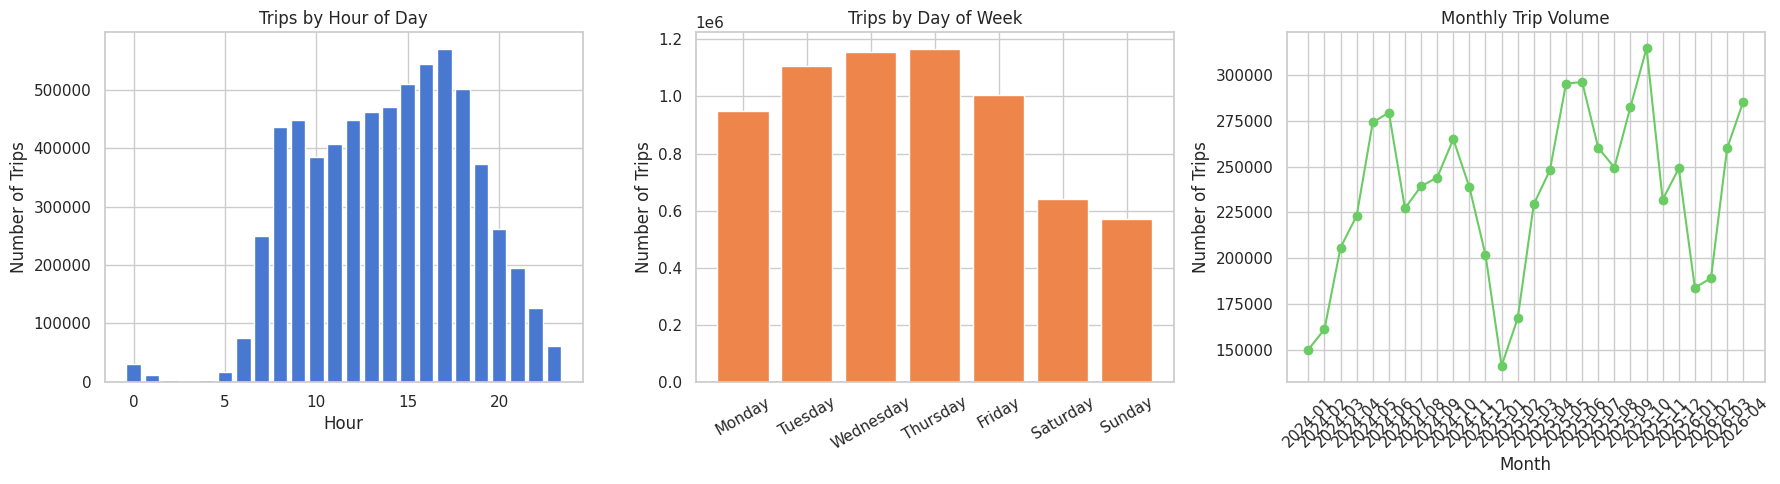

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df["hour"]      = df["trip_start_timestamp"].dt.hour
df["dayofweek"] = df["trip_start_timestamp"].dt.day_name()
df["month"]     = df["trip_start_timestamp"].dt.tz_localize(None).dt.to_period("M")

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trips_by_hour = df["hour"].value_counts().sort_index()
axes[0].bar(trips_by_hour.index, trips_by_hour.values, color=sns.color_palette("muted")[0])
axes[0].set_title("Trips by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Number of Trips")

trips_by_dow = df["dayofweek"].value_counts().reindex(DAY_ORDER)
axes[1].bar(trips_by_dow.index, trips_by_dow.values, color=sns.color_palette("muted")[1])
axes[1].set_title("Trips by Day of Week")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylabel("Number of Trips")

trips_by_month = df["month"].value_counts().sort_index()
axes[2].plot(trips_by_month.index.astype(str), trips_by_month.values, marker="o", color=sns.color_palette("muted")[2])
axes[2].set_title("Monthly Trip Volume")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Number of Trips")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Trip Characteristics

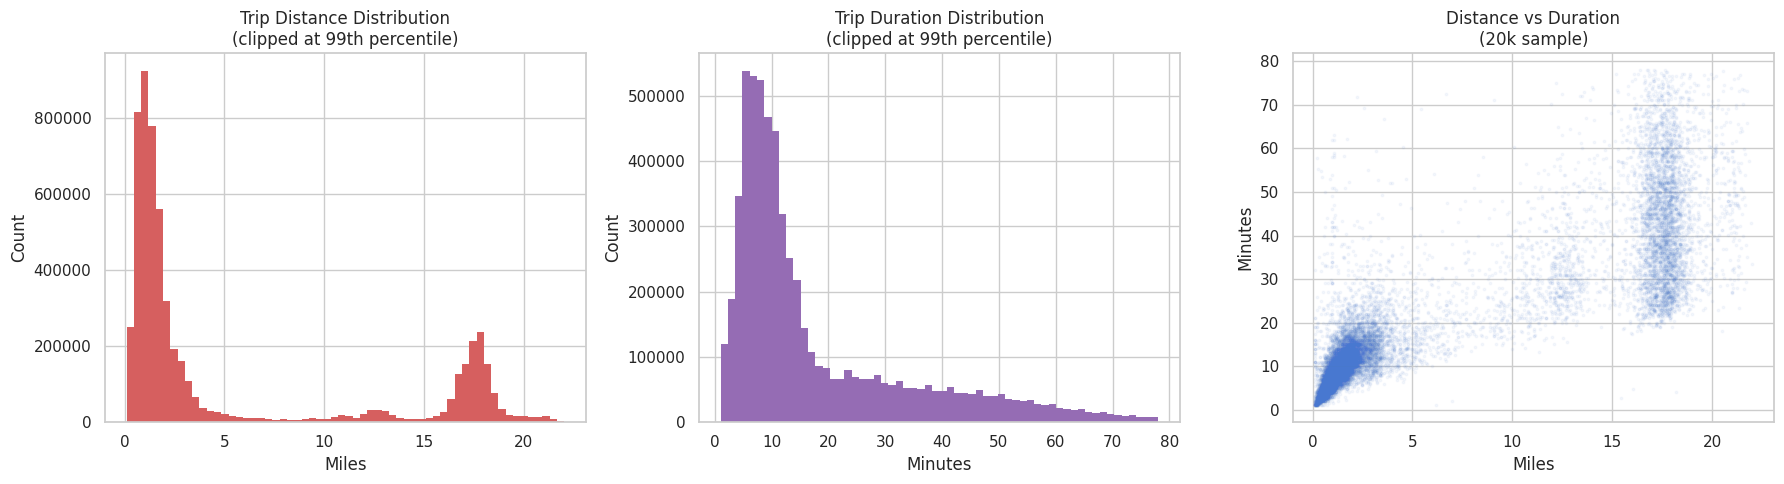

In [7]:
df["trip_minutes"] = df["trip_seconds"] / 60

MILES_MAX   = df["trip_miles"].quantile(0.99)
MINUTES_MAX = df["trip_minutes"].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clean_miles = df.loc[df["trip_miles"].between(0.1, MILES_MAX), "trip_miles"]
axes[0].hist(clean_miles, bins=60, color=sns.color_palette("muted")[3], edgecolor="none")
axes[0].set_title("Trip Distance Distribution\n(clipped at 99th percentile)")
axes[0].set_xlabel("Miles")
axes[0].set_ylabel("Count")

clean_min = df.loc[df["trip_minutes"].between(1, MINUTES_MAX), "trip_minutes"]
axes[1].hist(clean_min, bins=60, color=sns.color_palette("muted")[4], edgecolor="none")
axes[1].set_title("Trip Duration Distribution\n(clipped at 99th percentile)")
axes[1].set_xlabel("Minutes")
axes[1].set_ylabel("Count")

# Scatter sampled to 20k points for performance
scatter_df = df[["trip_miles", "trip_minutes"]].dropna()
scatter_df = scatter_df[
    scatter_df["trip_miles"].between(0.1, MILES_MAX) &
    scatter_df["trip_minutes"].between(1, MINUTES_MAX)
].sample(min(20_000, len(scatter_df)), random_state=42)
axes[2].scatter(scatter_df["trip_miles"], scatter_df["trip_minutes"], alpha=0.05, s=3, color=sns.color_palette("muted")[0])
axes[2].set_title("Distance vs Duration\n(20k sample)")
axes[2].set_xlabel("Miles")
axes[2].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

## Financial Overview

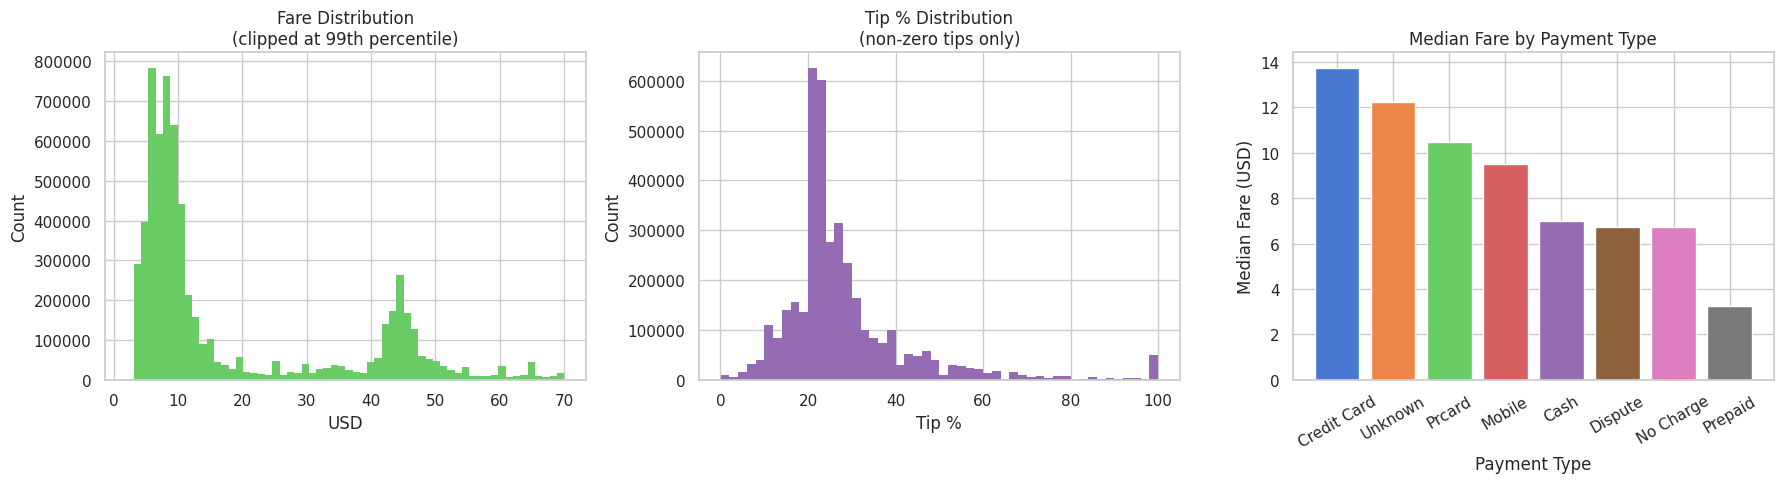

In [8]:
FARE_MAX = df["fare"].quantile(0.99)

df["tip_pct"] = (df["tips"] / df["fare"].replace(0, pd.NA) * 100).clip(0, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clean_fare = df.loc[df["fare"].between(2, FARE_MAX), "fare"]
axes[0].hist(clean_fare, bins=60, color=sns.color_palette("muted")[2], edgecolor="none")
axes[0].set_title("Fare Distribution\n(clipped at 99th percentile)")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Count")

clean_tip = df["tip_pct"].dropna()
clean_tip = clean_tip[clean_tip > 0]
axes[1].hist(clean_tip, bins=50, color=sns.color_palette("muted")[4], edgecolor="none")
axes[1].set_title("Tip % Distribution\n(non-zero tips only)")
axes[1].set_xlabel("Tip %")
axes[1].set_ylabel("Count")

med_fare = df.groupby("payment_type")["fare"].median().sort_values(ascending=False)
axes[2].bar(med_fare.index, med_fare.values, color=sns.color_palette("muted"))
axes[2].set_title("Median Fare by Payment Type")
axes[2].set_xlabel("Payment Type")
axes[2].set_ylabel("Median Fare (USD)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Companies & Payment Types (Top N)

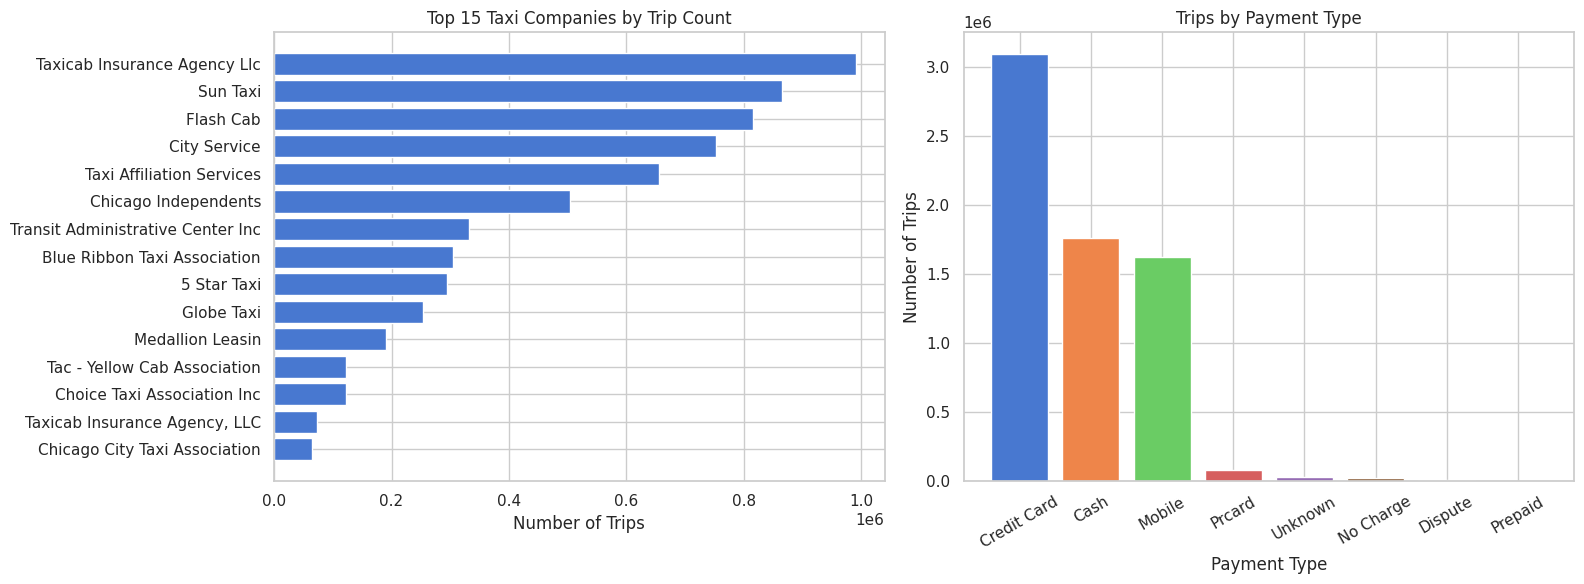

In [9]:
TOP_N = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_companies = df["company"].value_counts().head(TOP_N)
axes[0].barh(top_companies.index[::-1], top_companies.values[::-1], color=sns.color_palette("muted")[0])
axes[0].set_title(f"Top {TOP_N} Taxi Companies by Trip Count")
axes[0].set_xlabel("Number of Trips")

payment_counts = df["payment_type"].value_counts()
axes[1].bar(payment_counts.index, payment_counts.values, color=sns.color_palette("muted"))
axes[1].set_title("Trips by Payment Type")
axes[1].set_xlabel("Payment Type")
axes[1].set_ylabel("Number of Trips")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Geographic Patterns

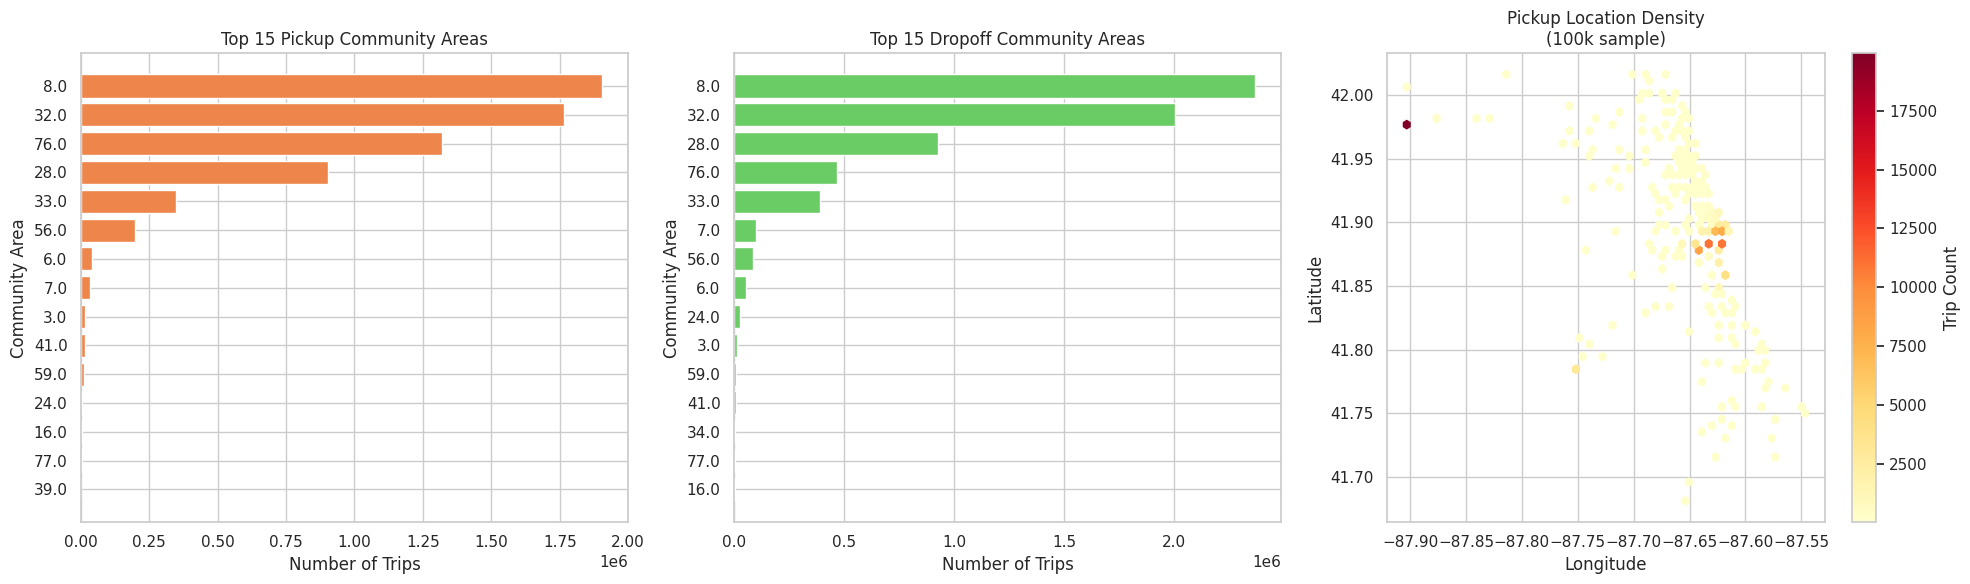

In [10]:
TOP_CA = 15

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_pickup = df["pickup_community_area"].value_counts().head(TOP_CA)
axes[0].barh(top_pickup.index.astype(str)[::-1], top_pickup.values[::-1], color=sns.color_palette("muted")[1])
axes[0].set_title(f"Top {TOP_CA} Pickup Community Areas")
axes[0].set_xlabel("Number of Trips")
axes[0].set_ylabel("Community Area")

top_dropoff = df["dropoff_community_area"].value_counts().head(TOP_CA)
axes[1].barh(top_dropoff.index.astype(str)[::-1], top_dropoff.values[::-1], color=sns.color_palette("muted")[2])
axes[1].set_title(f"Top {TOP_CA} Dropoff Community Areas")
axes[1].set_xlabel("Number of Trips")
axes[1].set_ylabel("Community Area")

# Hexbin of pickup density — sample 100k for performance
geo = df[["pickup_centroid_longitude", "pickup_centroid_latitude"]].dropna()
geo = geo[
    geo["pickup_centroid_longitude"].between(-87.95, -87.5) &
    geo["pickup_centroid_latitude"].between(41.6, 42.1)
].sample(min(100_000, len(geo)), random_state=42)

hb = axes[2].hexbin(
    geo["pickup_centroid_longitude"], geo["pickup_centroid_latitude"],
    gridsize=60, mincnt=1, cmap="YlOrRd"
)
plt.colorbar(hb, ax=axes[2], label="Trip Count")
axes[2].set_title("Pickup Location Density\n(100k sample)")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")

plt.tight_layout()
plt.show()